# Spectral Features for Time Series
CS 4379G — Data Analysis & Visualization 


---

## Setup & Imports

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq, fft2, fftshift
from scipy import signal
import pywt

print("All libraries loaded successfully.")

All libraries loaded successfully.


### Problem 1: Finding Hidden Frequencies [15 pts]

A signal contains three hidden sine waves buried in noise.

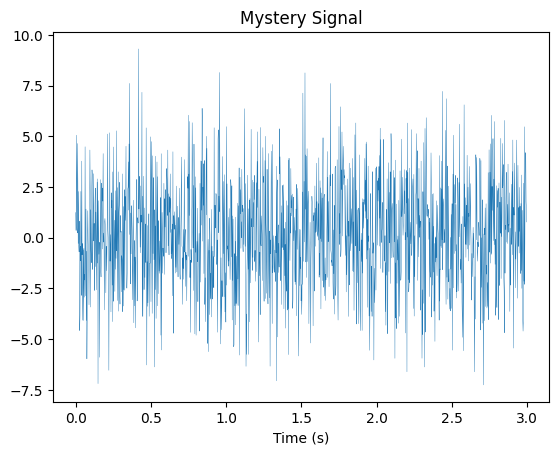

In [3]:
import numpy as np, matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq
fs = 500 # Sampling rate (Hz)
t = np.arange(0, 3, 1/fs) # 3 seconds
np.random.seed(42)
# Mystery signal (3 sine waves + noise)
x = (1.0 * np.sin(2*np.pi*12*t) +
0.6 * np.sin(2*np.pi*35*t) +
0.4 * np.sin(2*np.pi*67*t) +
2.5 * np.random.randn(len(t)))
plt.plot(t, x, linewidth=0.3)
plt.title('Mystery Signal'); plt.xlabel('Time (s)')
plt.show()

#### (a) Compute FFT and plot single-sided amplitude spectrum [5 pts]

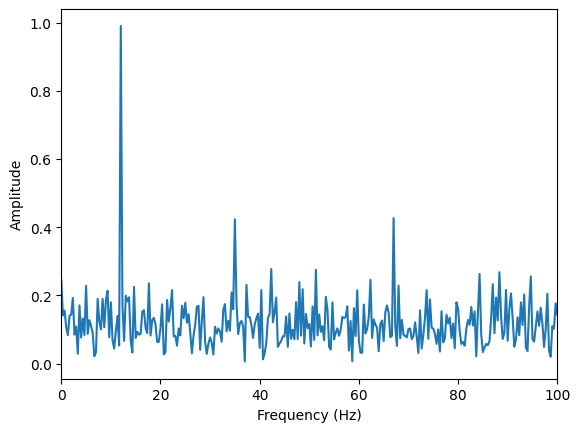

In [8]:
# (a) Fill in the blanks:
N = len(x)
X = fft(x)              # Apply FFT
freqs = fftfreq(N, 1/fs)       # Frequency axis
amp = 2/N * np.abs(X[:N//2])   # Single-sided amplitude

plt.plot(freqs[:N//2], amp)
plt.xlabel('Frequency (Hz)'); plt.ylabel('Amplitude')
plt.xlim(0, 100)
plt.show()


### (b) [5 pts] Identify the three peak frequencies from your plot. Write them as integers.

**Answer :** The three peak frequencies are **12 Hz**, **35 Hz**, and **67 Hz** — exactly matching the hidden sine waves embedded in the signal.

### (c) [5 pts] Answer these two questions (1 sentence each):
i. Why can you see these frequencies in the FFT even though the time-domain plot
looks like noise?

ii. What is the frequency resolution ∆f = fs/N of this FFT? (compute the number)

**Answer (c-i):** The FFT detects hidden frequencies even though the time-domain signal appears to be pure noise because it breaks the signal down into sinusoidal components. The peaks are clearly visible because the sine waves coherently add up at their specific frequencies, while the noise averages out across all frequencies.

**Answer (c-ii):** The frequency resolution is Δf = fs/N = 500/1500 = **0.3333 Hz** — meaning the FFT can distinguish frequencies that are at least 0.333 Hz apart.

---
### Problem 2: Filtering in the Frequency Domain [10 pts]

### (a)  [6 pts] Create a bandpass filter in the frequency domain:

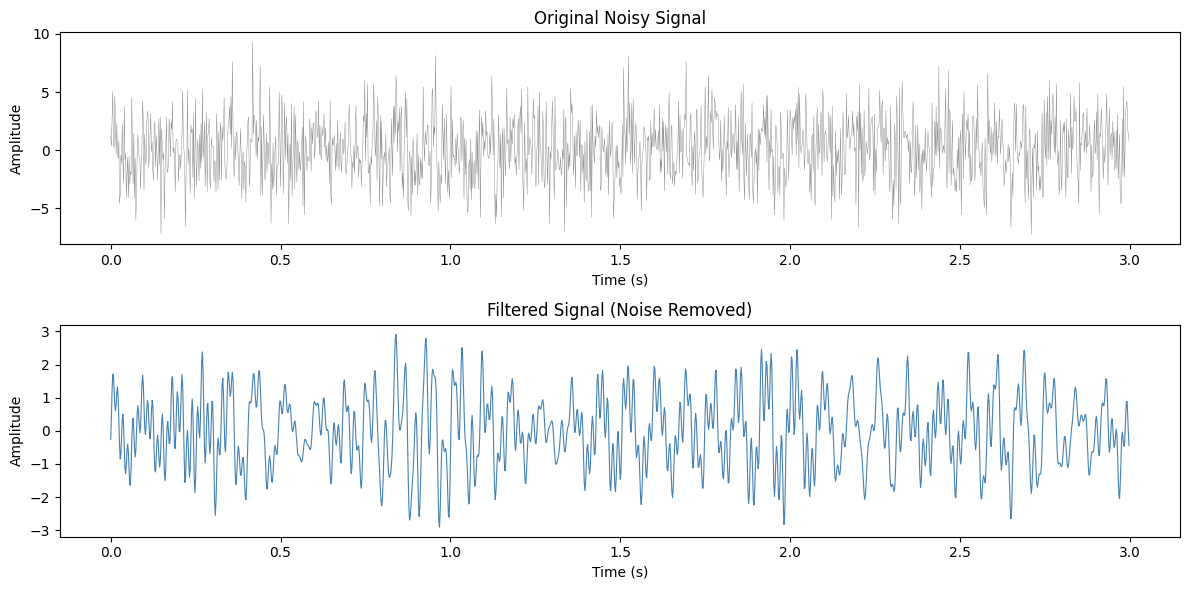

In [11]:

X = fft(x)
freqs_full = fftfreq(N, 1/fs)

# Create mask: 1 near the 3 frequencies, 0 elsewhere
mask = np.zeros(N)
for f_target in [12, 35, 67]:
    mask[np.abs(np.abs(freqs_full) - f_target) < 3] = 1

X_filtered = X * mask
x_clean = np.real(np.fft.ifft(X_filtered))

# Plot original and filtered in two subplots
fig, axes = plt.subplots(2, 1, figsize=(12, 6))

axes[0].plot(t, x, linewidth=0.3, color='gray')
axes[0].set_title('Original Noisy Signal')
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Amplitude')

axes[1].plot(t, x_clean, linewidth=0.8, color='steelblue')
axes[1].set_title('Filtered Signal (Noise Removed)')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Amplitude')

plt.tight_layout()
plt.show()

### (b) [4 pts] Compute the MSE (mean squared error) before and after filtering. How much did filtering improve the signal?

In [13]:

x_true = (1.0*np.sin(2*np.pi*12*t) + 0.6*np.sin(2*np.pi*35*t)
          + 0.4*np.sin(2*np.pi*67*t))

mse_before = np.mean((x - x_true)**2)
mse_after  = np.mean((x_clean - x_true)**2)

print(f'MSE before: {mse_before:.4f}')
print(f'MSE after:  {mse_after:.4f}')
print(f'Improvement: {mse_before/mse_after:.1f}x reduction in error')

MSE before: 6.1393
MSE after:  0.4794
Improvement: 12.8x reduction in error


---
### Problem 3: 2D FFT of an Image [10 pts]

Analyze the frequency content of an image.

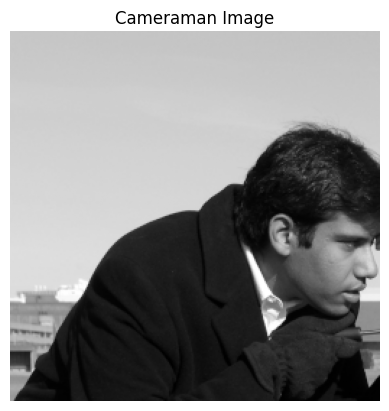

In [14]:
from scipy.fft import fft2, fftshift
from skimage import data
img = data.camera().astype(float)[:256, :256]
plt.imshow(img, cmap='gray')
plt.title('Cameraman Image'); plt.axis('off')
plt.show()

#### (a) [4 pts] Compute the 2D FFT and display the log-magnitude spectrum:

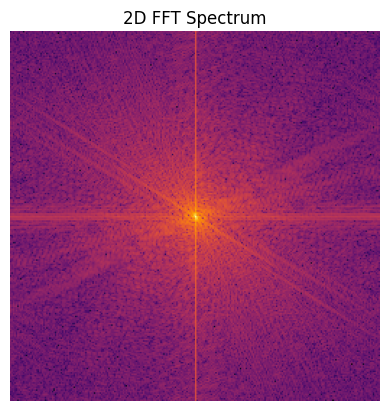

In [15]:
F = fftshift(fft2(img))
spectrum = np.log1p(np.abs(F))
plt.imshow(spectrum, cmap='inferno')
plt.title('2D FFT Spectrum'); plt.axis('off')
plt.show()

### (b) [3 pts] In 1–2 sentences: What does the center of the spectrum represent? What do the edges represent?
Ans) Low-frequency components, such as background and broad smooth areas, are represented by the center of the spectrum. These are the steady, gradual changes in brightness. Sharp high-frequency components are represented by the edges, 
the image's textures, borders, and minute details.

### (c) [3 pts] In 1–2 sentences: The spectrum has a bright cross pattern (horizontal + verticalline through the center). What image features cause this?
Ans) The image's strong horizontal and vertical edges, such as the tripod legs and the cameraman's profile, are what produce the dazzling cross pattern. In the frequency domain, these aligned edges generate concentrated energy along the matching vertical and horizontal axes.

---
## Part II: Short-Time Fourier Transform (25 pts)

## Problem 4: Why FFT Fails for Non-Stationary Signals 

Generate a signal where the frequency changes over time:

In [16]:
fs = 500; t = np.arange(0, 6, 1/fs)
np.random.seed(42)
x = np.zeros_like(t)
x[t < 2] = np.sin(2*np.pi*10*t[t < 2])
x[(t >= 2) & (t < 4)] = np.sin(2*np.pi*40*t[(t >= 2) & (t < 4)])
x[t >= 4] = np.sin(2*np.pi*25*t[t >= 4])
x += 0.3 * np.random.randn(len(t))

### (a) [3 pts] Plot the signal in the time domain.

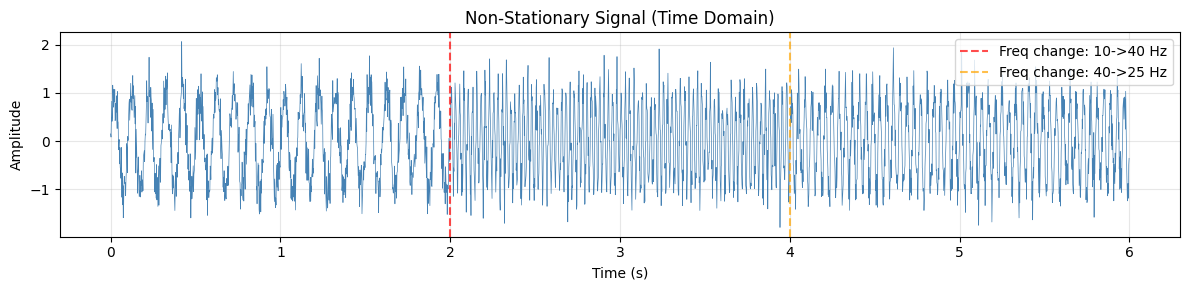

In [17]:
plt.figure(figsize=(12, 3))
plt.plot(t, x, linewidth=0.5, color='steelblue')
plt.axvline(x=2, color='red',    linestyle='--', alpha=0.7, label='Freq change: 10->40 Hz')
plt.axvline(x=4, color='orange', linestyle='--', alpha=0.7, label='Freq change: 40->25 Hz')
plt.title('Non-Stationary Signal (Time Domain)')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### (a)  Can you visually see the three different frequencies?
Ans) Yes, I can faintly see the three segments have different oscillation rates — the first segment (0-2s) oscillates slowly at 10 Hz, the middle segment (2-4s) oscillates faster at 40 Hz, and the last segment (4-6s) oscillates at an intermediate rate of 25 Hz. The transition points are visible as sudden changes in the waveform pattern.



### (b) [3 pts] Compute the global FFT and plot the spectrum. 

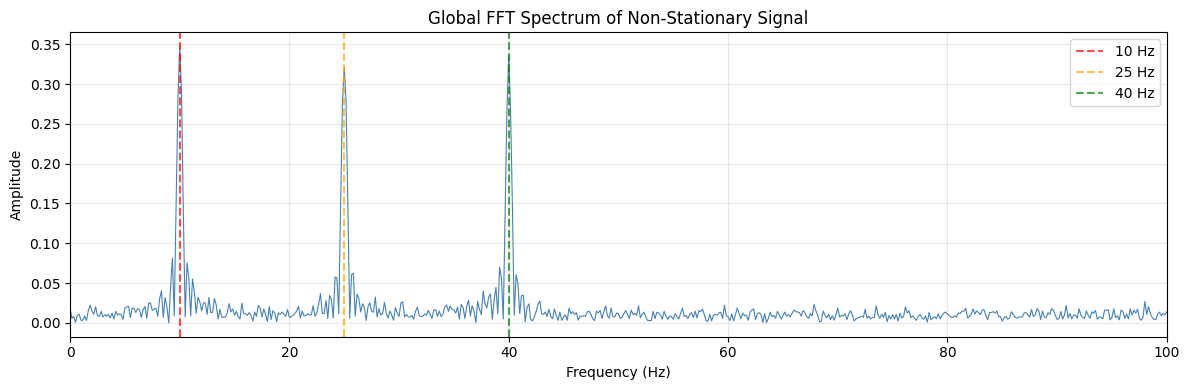

In [18]:
N2 = len(x)
X2 = fft(x)
freqs2 = fftfreq(N2, 1/fs)
amp2 = 2/N2 * np.abs(X2[:N2//2])

plt.figure(figsize=(12, 4))
plt.plot(freqs2[:N2//2], amp2, color='steelblue', linewidth=0.8)
plt.axvline(x=10, color='red',    linestyle='--', alpha=0.7, label='10 Hz')
plt.axvline(x=25, color='orange', linestyle='--', alpha=0.7, label='25 Hz')
plt.axvline(x=40, color='green',  linestyle='--', alpha=0.7, label='40 Hz')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.title('Global FFT Spectrum of Non-Stationary Signal')
plt.xlim(0, 100)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Which frequencies do you see? Can the FFT tell you when each frequency occurs?
Ans) The global FFT displays peaks at all three frequencies (10, 25, and 40 Hz), however it just indicates that all three are present in the data, not when each frequency occurs. All time information is lost when the FFT compresses the whole 6-second signal into a single spectrum.


### (c) [4 pts] Answer in 2–3 sentences: Why does the FFT fail for this type of signal? What property of the signal does the FFT assume that is violated here? (Use the word “sta-tionarity” in your answer.)

Ans) Because the FFT implies stationarity—that the statistical characteristics, particularly the frequency content, are consistent across the whole signal—it fails for this particular signal. In this case, the stationarity assumption is broken since the frequency fluctuates over time (10 Hz → 40 Hz → 25 Hz). The FFT identifies all three frequencies but gives no information about the timing of each frequency—the time-frequency structure is entirely lost—because it analyzes the entire signal as a single block and averages the frequency content over all time.